In [1]:
import pandas as pd
from prophet import Prophet
import matplotlib.pyplot as plt

daily_demand = pd.read_csv("../data/processed/daily_demand.csv")
daily_demand['order_date'] = pd.to_datetime(daily_demand['order_date'])

df_prophet = daily_demand[['order_date', 'total_qty']].rename(
    columns={'order_date': 'ds', 'total_qty': 'y'})

print(df_prophet.shape)
df_prophet.head()

Importing plotly failed. Interactive plots will not work.


(616, 2)


,ds,y
0,2025-01-22,16
1,2025-01-23,0
2,2025-01-24,0
3,2025-01-25,0
4,2025-01-26,0


15:44:01 - cmdstanpy - INFO - Chain [1] start processing


15:44:01 - cmdstanpy - INFO - Chain [1] done processing


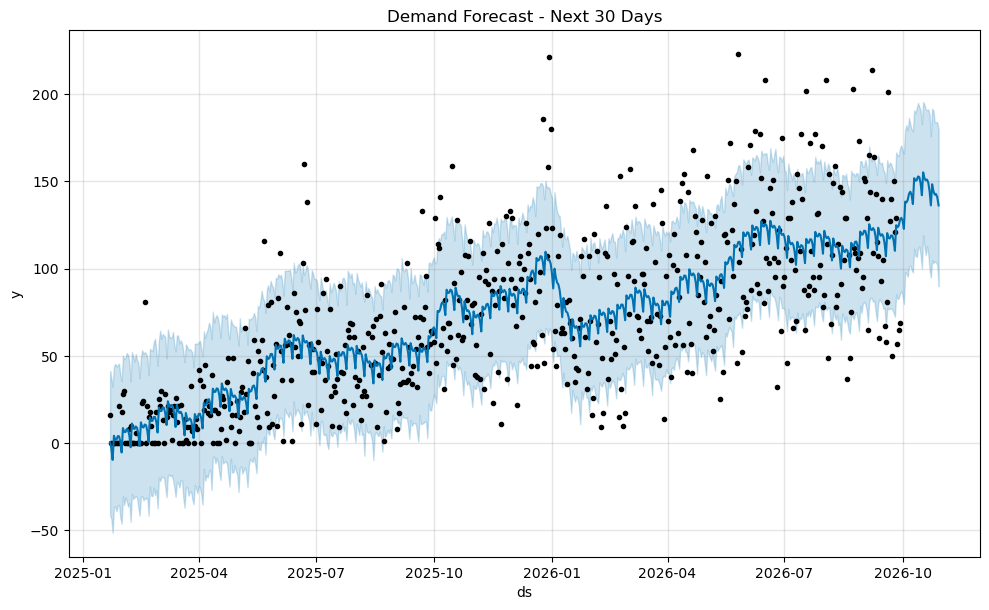

In [2]:
model = Prophet(yearly_seasonality=True, weekly_seasonality=True)
model.fit(df_prophet)

future = model.make_future_dataframe(periods=30)
forecast = model.predict(future)

fig = model.plot(forecast)
plt.title("Demand Forecast - Next 30 Days")
plt.show()

In [3]:
forecast_out = forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].rename(
    columns={'ds': 'date', 'yhat': 'predicted_qty',
             'yhat_lower': 'lower_bound', 'yhat_upper': 'upper_bound'})
forecast_out.to_csv("../reports/demand_forecast.csv", index=False)
print("Saved demand_forecast.csv")
forecast_out.tail(10)

Saved demand_forecast.csv


,date,predicted_qty,lower_bound,upper_bound
636,2026-10-20,151.037459,112.919947,190.775990
637,2026-10-21,149.184138,108.047323,191.187418
638,2026-10-22,144.323793,99.575581,188.065620
639,2026-10-23,136.203064,94.752821,175.830822
640,2026-10-24,148.335183,104.849779,191.559674
641,2026-10-25,144.361622,103.040672,190.503758
642,2026-10-26,142.454356,104.061969,183.822399
643,2026-10-27,142.704966,103.750073,183.977672
644,2026-10-28,140.833518,102.017265,183.819158
645,2026-10-29,136.197111,89.887239,179.600774
